# A 2-layer GCN, from scratch

**Session 10 — Graph Neural Networks**

A Graph Convolutional Network learns node representations by **message passing**: each node's new representation is a function of its own features *and* its neighbours' features. Stack two such layers and every node sees its 2-hop neighbourhood.

The forward pass for a layer is one line of linear algebra:

$$H' \;=\; \sigma\!\left( \hat A \, H \, W \right)$$

where $\hat A$ is the symmetrically normalised adjacency with self-loops (Kipf & Welling 2017):

$$\tilde A = A + I, \qquad \hat A = \tilde D^{-1/2} \, \tilde A \, \tilde D^{-1/2}.$$

**Comparison with the session 08 DeepWalk demo:**

| | DeepWalk (sess. 08) | GCN (this demo) |
|---|---|---|
| Supervision | Unsupervised (walks) | Semi-supervised (CE) |
| Uses node features? | No | Yes |
| Inductive on new nodes? | No | Yes |
| Forward pass | Embedding lookup | Message passing |

We re-use the **same 3-community stochastic-block-model graph** from session 08 so the two demos can be compared directly.

**Run:**
```bash
pip install torch numpy matplotlib networkx
```

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import networkx as nx

torch.manual_seed(0)
rng = np.random.default_rng(0)

## 1. Same SBM graph as the session-08 DeepWalk demo

3 communities × 20 nodes = **60 nodes**. Within-community edge probability `P_IN = 0.20`, between-community probability `P_OUT = 0.015`.

In [2]:
N_COMMUNITIES = 3
NODES_PER_COMM = 20
P_IN, P_OUT = 0.20, 0.015
COMMUNITY_COLORS = ["#e63946", "#2a9d8f", "#457b9d"]

sizes = [NODES_PER_COMM] * N_COMMUNITIES
probs = np.full((N_COMMUNITIES, N_COMMUNITIES), P_OUT)
np.fill_diagonal(probs, P_IN)
G = nx.stochastic_block_model(sizes, probs, seed=0)
N = G.number_of_nodes()
community = np.array([G.nodes[v]["block"] for v in G.nodes])
print(f"{N} nodes, {G.number_of_edges()} edges, {N_COMMUNITIES} communities")

60 nodes, 136 edges, 3 communities


## 2. Build the normalised adjacency $\hat A$

**Why self-loops?** Without them, a layer's output for node $v$ wouldn't include $v$'s own features at all — only the neighbours'. Adding $I$ keeps the node's own information in the mix.

**Why symmetric normalisation?** A high-degree node would otherwise dominate the messages it sends. The $\tilde D^{-1/2}$ scaling on both sides makes the message magnitudes comparable across nodes regardless of degree.

In [3]:
A = nx.to_numpy_array(G) + np.eye(N)         # add self-loops
D = A.sum(axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(D))
A_hat = torch.tensor(D_inv_sqrt @ A @ D_inv_sqrt, dtype=torch.float32)
print(f"A_hat shape: {A_hat.shape}, row sums: {A_hat.sum(1)[:5].numpy()} ...")

A_hat shape: torch.Size([60, 60]), row sums: [1.         0.73412544 0.9070925  0.78242564 0.9125891 ] ...


## 3. Featureless setup: $X = I$

Real graphs sometimes carry node features (text, images, attributes), sometimes not. When they don't, the canonical fallback is to use **$X = I$** — a one-hot per node. Layer-1 weights then act as a *learnable embedding lookup*, but unlike DeepWalk, the lookups are immediately averaged with their neighbours by GCN aggregation, so message passing kicks in from the first layer.

Important: at no point does the model see the community labels through `X`. The signal comes entirely from the graph structure encoded in $\hat A$.

In [4]:
F_DIM = N
X = torch.eye(N, dtype=torch.float32)

## 4. The GCN: two layers, eight lines of code

$$H = \sigma(\hat A \, X \, W_1), \qquad \text{logits} = \hat A \, H \, W_2$$

Two `nn.Linear` (no bias), one ReLU, two adjacency multiplications. That's the whole architecture.

In [5]:
class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, n_classes):
        super().__init__()
        # self.W1 è la matrice dei pesi della rete neurale per il primo Layer.
        # Usa bias=False per mantenere la formula matematica pura (senza costanti aggiuntive).
        self.W1 = nn.Linear(in_dim, hidden_dim, bias=False)
        
        # self.W2 è la matrice dei pesi per il secondo Layer. 
        # Comprime i dati nascosti per far uscire un numero di valori pari alle fazioni (n_classes).
        self.W2 = nn.Linear(hidden_dim, n_classes, bias=False)

    # Il forward pass riceve la topologia (A_hat) e le features dei nodi (X)
    def forward(self, A_hat, X):
        
        # LIVELLO 1: Traduzione esatta della formula H' = sigma(A_hat * X * W)
        # - self.W1(X) applica i pesi alle features dei nodi.
        # - L'operatore '@' fa la moltiplicazione matriciale con A_hat (il Message Passing!).
        # - F.relu è la nostra funzione di attivazione sigma.
        H = F.relu(A_hat @ self.W1(X))     
        
        # LIVELLO 2: Prende l'output del primo livello (H) e ripete il processo.
        # Non si usa la ReLU qui perché vogliamo i "logits" (i punteggi grezzi finali) 
        # che poi la funzione di Loss trasformerà in probabilità.
        logits = A_hat @ self.W2(H)         
        
        return H, logits

HIDDEN = 16
# Inizializza il modello definendo la grandezza in entrata, quella nascosta e quella in uscita.
model = GCN(F_DIM, hidden_dim=HIDDEN, n_classes=N_COMMUNITIES)

# Ottimizzatore Adam con "weight_decay" (Regolarizzazione L2 per evitare che i pesi diventino enormi)
opt = torch.optim.Adam(model.parameters(), lr=0.05, weight_decay=5e-4)

# Conta quanti parametri (numeri singoli) la rete neurale deve imparare
n_params = sum(p.numel() for p in model.parameters())
print(f"GCN: {n_params:,} parameters")

GCN: 1,008 parameters


## 5. Semi-supervised split: 4 labels per community

We label only **4 nodes per community** (12 of 60). The cross-entropy loss is computed only on those 12 nodes. The other 48 are evaluated for accuracy at every epoch but never seen by the loss.

In [13]:
# Crea un array di zeri (Falso) lungo quanto tutto il grafo. Nessuno è etichettato all'inizio.
labeled_mask = np.zeros(N, dtype=bool)
# Cicla per ogni comunità presente nel grafo (es. le 3 comunità del blocco stocastico)
for c in range(N_COMMUNITIES):
    # Trova tutti i nodi che appartengono a questa specifica comunità
    in_comm = np.where(community == c)[0]
    
    # Sceglie esattamente 4 nodi A CASO (senza reinserimento) da questa comunità
    chosen = rng.choice(in_comm, size=4, replace=False)
    
    # Segna solo questi 4 nodi come "Veri" (Etichettati) nella maschera
    labeled_mask[chosen] = True

# Converte gli indici e le etichette in Tensori PyTorch per l'addestramento
train_idx = torch.tensor(np.where(labeled_mask)[0], dtype=torch.long)
labels = torch.tensor(community, dtype=torch.long)

# Stampa la percentuale di nodi di cui l'IA conosce la risposta
print(f"Labelled: {labeled_mask.sum()} / {N} = {labeled_mask.sum()/N:.0%}")

[4. 5. 6.]
Labelled: 12 / 60 = 20%


## 6. Train, snapshotting the hidden layer

Same trick as the previous demos. The hidden layer is 16-dimensional, so for visualisation we project to 2D with PCA. We use the PCA basis of the **final** snapshot for *all* snapshots, so all panels share an axis system and the geometry is comparable across epochs.

In [18]:
# Una funzione per proiettare i dati in 2D (PCA) per vederli sullo schermo
def pca_2d(H, basis=None):
    Hc = H - H.mean(0, keepdims=True)
    if basis is None:
        _, _, Vt = np.linalg.svd(Hc, full_matrices=False)
        basis = Vt[:2].T
    return Hc @ basis, basis

# Prepariamo la "macchina fotografica" per salvare lo stato della rete in queste epoche
SNAPSHOTS = [0, 5, 25, 100, 300]
N_EPOCHS = SNAPSHOTS[-1] + 1

snaps_H, losses, test_accs = {}, [], []
for epoch in range(N_EPOCHS):
    
    # 1. SCATTA LA FOTO: se siamo in un'epoca-snapshot, salva le coordinate (H)
    if epoch in SNAPSHOTS:
        with torch.no_grad(): # Spegni il calcolo dei gradienti per non inquinare l'addestramento
            H, _ = model(A_hat, X)
            snaps_H[epoch] = H.numpy().copy()

    # 2. ADDESTRAMENTO VERO E PROPRIO: Calcola i nuovi bigliettini (H) e le probabilità (logits)
    H, logits = model(A_hat, X)
    
    # Calcola l'errore (Loss) SOLO SUI NODI ETICHETTATI (i famosi 12 nodi scelti prima)
    loss = F.cross_entropy(logits[train_idx], labels[train_idx])
    
    # La trinità di PyTorch: azzera la memoria, calcola all'indietro, aggiorna i pesi W1 e W2
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

    # 3. VERIFICA SUI NODI NASCOSTI: L'IA sta capendo anche i nodi senza etichetta?
    with torch.no_grad():
        pred = logits.argmax(-1).numpy()
    # Confronta le predizioni con la verità solo per i nodi NON etichettati (~labeled_mask)
    test_accs.append((pred[~labeled_mask] == community[~labeled_mask]).mean())

# Applica la PCA sull'ultima epoca per trovare l'angolo di visuale migliore, 
# e usa quello stesso angolo per tutte le foto precedenti.
_, basis = pca_2d(snaps_H[SNAPSHOTS[-1]])
snaps = {ep: pca_2d(H, basis=basis)[0] for ep, H in snaps_H.items()}

print(f"final loss = {losses[-1]:.3f}, "
      f"test accuracy on unlabelled nodes = {test_accs[-1]:.1%}")

[4. 5. 6.]
final loss = 0.006, test accuracy on unlabelled nodes = 93.8%


## 7. Watch the embeddings move

Stars = labelled nodes (the only nodes the loss ever sees). Circles = unlabelled nodes the model has to figure out from message passing alone.

Even after just 5 epochs, the labelled stars are already pulling apart along community-specific directions, and the unlabelled circles drift along with their respective stars — that's the message-passing aggregation propagating the supervision signal across the graph through the labelled nodes' neighbourhoods.

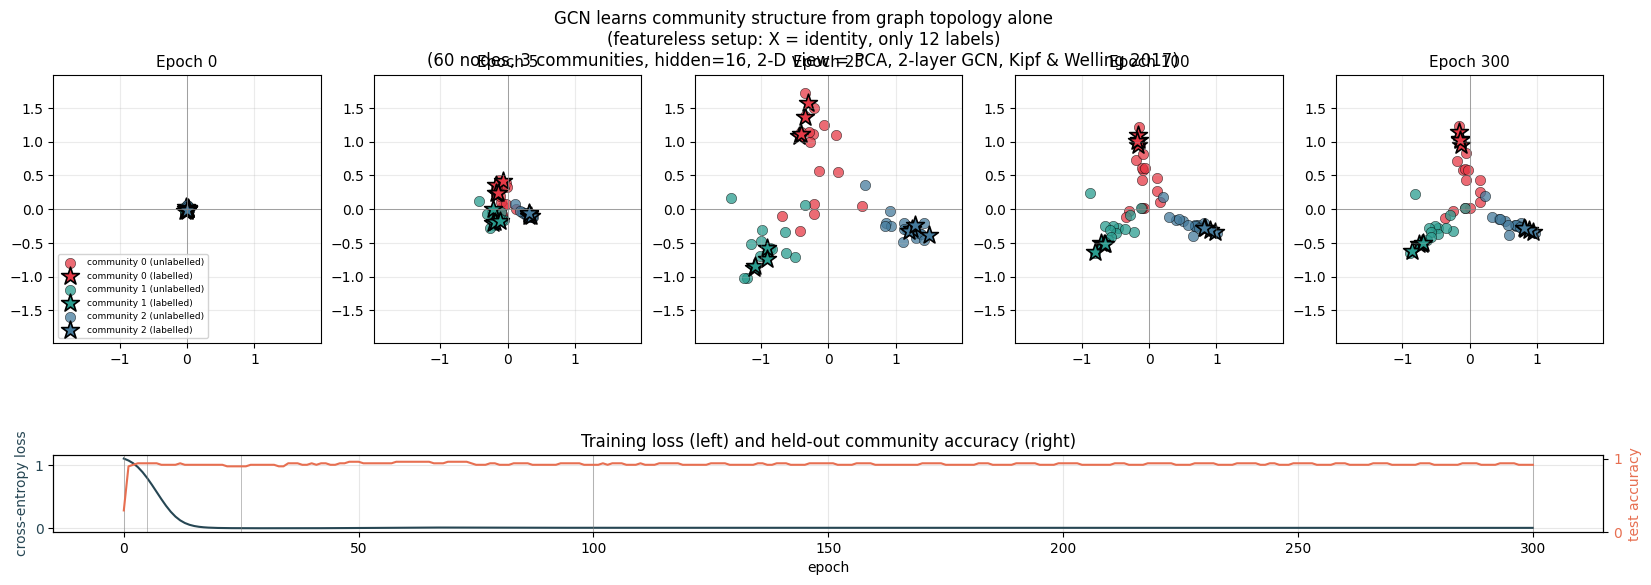

In [8]:
fig = plt.figure(figsize=(4 * len(SNAPSHOTS), 6.0))
gs = fig.add_gridspec(2, len(SNAPSHOTS), height_ratios=[4, 1.1], hspace=0.6)

all_pts = np.vstack(list(snaps.values()))
lim = max(abs(all_pts.min()), abs(all_pts.max())) * 1.15

for col, ep in enumerate(SNAPSHOTS):
    ax = fig.add_subplot(gs[0, col])
    Z = snaps[ep]
    for c in range(N_COMMUNITIES):
        m_un = (community == c) & ~labeled_mask
        ax.scatter(Z[m_un, 0], Z[m_un, 1], c=COMMUNITY_COLORS[c],
                   s=55, alpha=0.75, edgecolor='black', linewidth=0.4,
                   label=f'community {c} (unlabelled)' if col == 0 else None)
        m_lab = (community == c) & labeled_mask
        ax.scatter(Z[m_lab, 0], Z[m_lab, 1], c=COMMUNITY_COLORS[c],
                   s=180, marker='*', edgecolor='black', linewidth=1.2,
                   label=f'community {c} (labelled)' if col == 0 else None)
    ax.set_title(f"Epoch {ep}", fontsize=11)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect('equal'); ax.grid(alpha=0.25)
    ax.axhline(0, c='gray', lw=0.5); ax.axvline(0, c='gray', lw=0.5)
    if col == 0:
        ax.legend(fontsize=6.5, loc='lower left', framealpha=0.85)

ax_loss = fig.add_subplot(gs[1, :])
ax_loss.plot(losses, c='#264653', label='train loss')
ax_loss.set_xlabel("epoch"); ax_loss.set_ylabel("cross-entropy loss", color='#264653')
ax_loss.tick_params(axis='y', labelcolor='#264653'); ax_loss.grid(alpha=0.3)
ax_acc = ax_loss.twinx()
ax_acc.plot(test_accs, c='#e76f51', label='test acc (unlabelled)')
ax_acc.set_ylabel("test accuracy", color='#e76f51')
ax_acc.tick_params(axis='y', labelcolor='#e76f51'); ax_acc.set_ylim(0, 1.05)
for ep in SNAPSHOTS:
    ax_loss.axvline(ep, c='gray', lw=0.6, alpha=0.6)
ax_loss.set_title("Training loss (left) and held-out community accuracy (right)")

fig.suptitle(
    "GCN learns community structure from graph topology alone\n"
    "(featureless setup: X = identity, only 12 labels)\n"
    f"({N} nodes, {N_COMMUNITIES} communities, hidden={HIDDEN}, 2-D view = PCA, "
    "2-layer GCN, Kipf & Welling 2017)",
    fontsize=12,
)
plt.show()

## 8. Bonus: how few labels can we get away with?

Sweep the number of labels per community from 1 to 10 and plot the held-out test accuracy. This is the GCN's superpower — semi-supervised learning with very few labels.

  1 label(s)/community → 81.8%
  2 label(s)/community → 90.7%
  3 label(s)/community → 89.4%
  4 label(s)/community → 91.7%
  5 label(s)/community → 94.2%
  7 label(s)/community → 95.9%
  10 label(s)/community → 95.3%


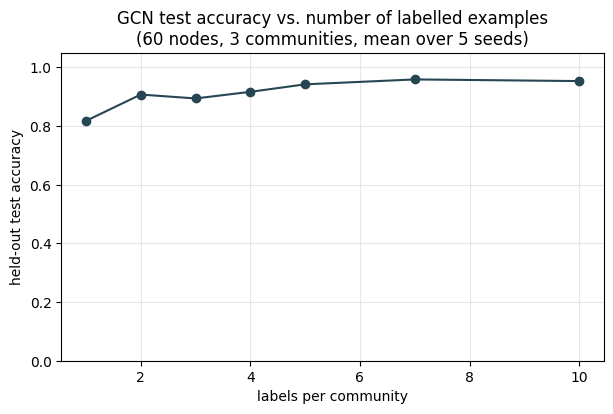

In [9]:
def train_gcn(labels_per_community, n_epochs=300, seed=0):
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    mask = np.zeros(N, dtype=bool)
    for c in range(N_COMMUNITIES):
        chosen = rng.choice(np.where(community == c)[0],
                            size=labels_per_community, replace=False)
        mask[chosen] = True
    train_idx = torch.tensor(np.where(mask)[0], dtype=torch.long)

    m = GCN(F_DIM, HIDDEN, N_COMMUNITIES)
    o = torch.optim.Adam(m.parameters(), lr=0.05, weight_decay=5e-4)
    for _ in range(n_epochs):
        _, logits = m(A_hat, X)
        loss = F.cross_entropy(logits[train_idx], labels[train_idx])
        o.zero_grad(); loss.backward(); o.step()
    with torch.no_grad():
        _, logits = m(A_hat, X)
        pred = logits.argmax(-1).numpy()
    return (pred[~mask] == community[~mask]).mean()

ks = [1, 2, 3, 4, 5, 7, 10]
# average over a few seeds for stable numbers
accs = []
# Ripeti il test 5 volte per ogni scenario e fanne la media per avere un risultato stabile
for k in ks:
    runs = [train_gcn(k, seed=s) for s in range(5)]
    accs.append(np.mean(runs))
    print(f"  {k} label(s)/community → {accs[-1]:.1%}")

plt.figure(figsize=(7, 4))
plt.plot(ks, accs, 'o-', color='#264653')
plt.xlabel("labels per community"); plt.ylabel("held-out test accuracy")
plt.title("GCN test accuracy vs. number of labelled examples\n(60 nodes, 3 communities, mean over 5 seeds)")
plt.ylim(0, 1.05); plt.grid(alpha=0.3)
plt.show()

## 9. Discussion

### What is message passing actually doing?

Layer 1 produces $H_1[v] = \sigma\!\big(\sum_{u \in \mathcal N(v) \cup \{v\}} \alpha_{vu}\, x_u W_1\big)$ for each node $v$, where $\alpha_{vu}$ comes from the normalised adjacency. Layer 2 does the same on $H_1$, so $H_2[v]$ depends on every node within **2 hops** of $v$. With our SBM graph, two nodes in the same community share most of their 2-hop neighbourhoods — so their $H_2$ representations are nearly identical, even when both nodes are unlabelled. That is why a handful of labels is enough to colour the rest of the graph correctly.

### Why is this called a "convolution"?

Aggregating with $\hat A$ is the graph analogue of convolving with a small kernel on a regular grid. The spectral picture: $\hat A$ has the same eigenvectors as the (normalised) graph Laplacian, so multiplying by $\hat A$ is a low-pass filter on the graph spectrum — it smooths features along graph edges. Two layers of GCN ≈ a quadratic polynomial filter on the graph spectrum, which is enough to separate well-clustered communities.

### How is this different from DeepWalk?

Both end up with node embeddings that respect graph proximity, but the **mechanisms** are different:

- DeepWalk: sample walks → train word2vec on (target, context) pairs. The embedding for node $v$ is just a row of a lookup table.
- GCN: $H[v] = $ a function of $v$'s features and its neighbourhood. The embedding is *computed*, not stored.

Two practical consequences:

1. **Inductive vs transductive.** If a new node arrives in the graph, DeepWalk has no embedding for it (we'd need to retrain). The GCN can compute one immediately by feeding the new node's features and edges through the same layers — no retraining needed.
2. **Node features.** DeepWalk treats nodes as opaque IDs. GCN can use real features (text, attributes, images). When you have features that are informative, the GCN gets a major boost; when you don't, the featureless setup we used here still works.

### Why does the GCN work even with random features?

(Try replacing `X = torch.eye(N)` with `X = torch.randn(N, 8)` and re-run.) With only 60 nodes and 12 labels, random Gaussian features struggle because the model has to extract a faint signal from very noisy inputs. Identity features sidestep this: each node gets its own learnable $W_1$ row, and message passing then averages those rows over the 2-hop neighbourhood. Two nodes in the same community get nearly identical aggregates → linearly separable in the hidden layer.

### Limits of GCN, and what comes next

- **Over-smoothing.** Stack too many GCN layers and every node's representation converges to the same vector — message passing keeps averaging until information is lost. In practice, 2–4 layers is the sweet spot for community-detection-style tasks.
- **Uniform aggregation.** GCN weights every neighbour the same way (modulo degree normalisation). **GAT** (Graph Attention Networks) lets the model learn per-edge attention weights, so important neighbours can dominate.
- **Inductive scaling.** On large graphs, computing $\hat A H W$ for the full graph at every step is expensive. **GraphSAGE** samples a fixed-size neighbourhood per node and trains in mini-batches.
- **Heterogeneous graphs.** Real graphs have multiple node and edge types (users / items / tags / friendships / purchases). Heterogeneous GNNs (R-GCN, HGT) extend message passing to typed edges.

All of those are refinements of the same recipe you saw here in ~50 lines: **aggregate from neighbours, project, repeat**.